# FEMTO RUL — Tez Görselleri

Yayın kalitesi (300 DPI, Türkçe, gri tonlamada okunur). PNG → `experiments/results/figures/`.
**Not:** Sağlıklı-faz filtresi tezden tamamen çıkarıldı; bu notebook'ta da yok.

| Şekil | Dosya | Tez | Durum |
|---|---|---|---|
| A. Rulman-başına bozulma sinyali çeşitliliği | `gorsel_sinyal_farkliliklari.png` | 3.1 / 5.1 | ✅ Lokal |
| B. Truncation / fiziksel limit (h_rms vs gerçek HI) | `gorsel_truncation.png` | 5.1 | ✅ Lokal |
| C. RF/XGB HI trajektorileri | `gorsel_trajektori_ml.png` | 4.2 | ✅ Lokal |
| D. Rulman-başına tahmin (tablo + bar) | `tablo_yatak_tahmin.csv` / `gorsel_yatak_tahmin.png` | 4.1 | ✅ Lokal |
| E. 5-model karşılaştırma (PHM / endpoint_r) | `gorsel_model_karsilastirma.png` | 4.1 | ⏳ DL=Colab |
| F. GRU/TCN/raw-TCN rulman-başına RUL tahmini | `gorsel_dl_rulman_tahmin.png` | 4.2 | ✅ Lokal |
| G. raw-TCN vs feature-DL (RQ2) | `gorsel_rq2_rawtcn.png` | 5.2 | ⏳ Colab |

In [1]:
# ── Kurulum: yayın-kalitesi stil + yollar ──────────────────────────────────────
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings("ignore")

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC  = BASE / "src"
sys.path.insert(0, str(SRC))
FIGDIR = BASE / "experiments" / "results" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 10,
})
# Uyumlu, ayırt edilebilir palet (Tableau-muted); her model farklı renk
C = {"rf": "#E15759", "xgb": "#59A14F",
     "gru": "#4E79A7", "tcn": "#F28E2B", "rawtcn": "#B07AA1",
     "actual": "#4C4C4C", "anom": "#E15759", "norm": "#4E79A7"}
# Görsellerde gösterilecek model adları (rawTCN bir algoritma adıymış gibi durmasın)
DISP = {"raw-TCN": "TCN (ham)"}

def save(fig, name):
    p = FIGDIR / name
    fig.savefig(p)
    print(f"  kaydedildi → {p.relative_to(BASE)}")

TR = pd.read_csv(BASE/"data"/"processed"/"features_train.csv")
TE = pd.read_csv(BASE/"data"/"processed"/"features_test.csv")
print("Kurulum tamam. train:", TR.shape, " test:", TE.shape)

Kurulum tamam. train: (7534, 63)  test: (13959, 63)


## Şekil H — Hedef Değişken: HI Etiketleme (3.2.6)  [eski Şekil 3.3'ün yerine]

**Mesaj:** Hedef, doğrudan (mutlak) RUL yerine **Sağlık Göstergesi (HI)** olarak tanımlanır:
`HI = clip((t − t*) / cap, 0, 1)` → sağlıklı fazda **0**, FPT'den (t*, CUSUM ile bulunur) sonra
doğrusal artıp arıza anında **1**. *(Sol)* tek rulmanda HI'nin ham titreşimle (h_rms) birlikte nasıl
oluştuğu; *(sağ)* tüm eğitim rulmanlarında HI — ömür uzunlukları farklı olsa da hepsi 0→1 arası
**rulmandan bağımsız** ortak bir hedef. Bu, eski piecewise-RUL etiketinin (Şekil 3.3) yerine geçer.

  kaydedildi → experiments/results/figures/gorsel_hi_etiketleme.png


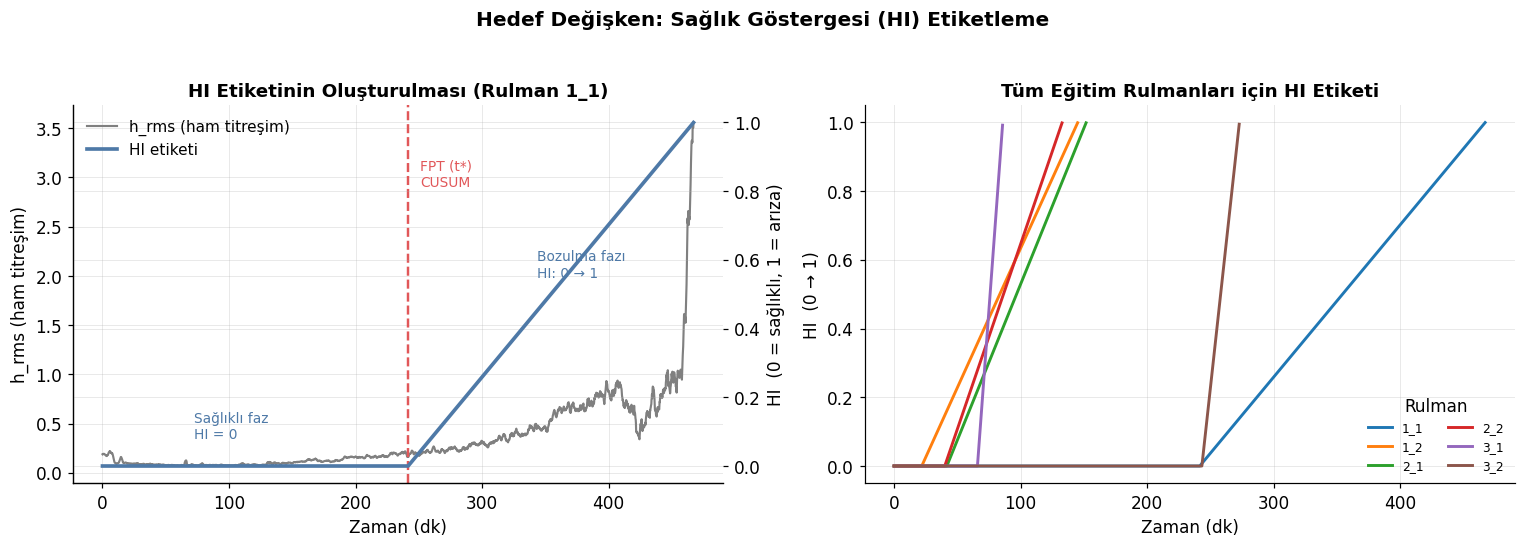

In [2]:
# Sol panel için örnek rulman (belirgin bozulma)
demo = "Bearing1_1"
g = TR[TR.bearing == demo].sort_values("time_s")
t_min = g["time_s"].values / 60.0
tstar_min = g["t_star_s"].iloc[0] / 60.0
cap = g["cap_s"].iloc[0]
hi = np.clip((g["time_s"].values - g["t_star_s"].iloc[0]) / cap, 0, 1)
rms = pd.Series(g["h_rms"].values).rolling(10, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
# (1) HI'nin oluşturulması
ax = axes[0]; ax2 = ax.twinx()
l1, = ax.plot(t_min, rms, color="gray", lw=1.4, label="h_rms (ham titreşim)")
l2, = ax2.plot(t_min, hi, color=C["norm"], lw=2.4, label="HI etiketi")
ax.axvline(tstar_min, color=C["anom"], ls="--", lw=1.6)
ax2.set_ylim(-0.05, 1.05)
ax.annotate("FPT (t*)\nCUSUM", (tstar_min, ax.get_ylim()[1]*0.78),
            xytext=(8, 0), textcoords="offset points", color=C["anom"], fontsize=9)
ax2.annotate("Sağlıklı faz\nHI = 0", (t_min[0]+(tstar_min-t_min[0])*0.3, 0.08), fontsize=9, color=C["norm"])
ax2.annotate("Bozulma fazı\nHI: 0 → 1", (tstar_min+(t_min[-1]-tstar_min)*0.45, 0.55), fontsize=9, color=C["norm"])
ax.set_xlabel("Zaman (dk)"); ax.set_ylabel("h_rms (ham titreşim)")
ax2.set_ylabel("HI  (0 = sağlıklı, 1 = arıza)")
ax.set_title(f"HI Etiketinin Oluşturulması ({demo.replace('Bearing','Rulman ')})")
ax.legend(handles=[l1, l2], loc="upper left")
# (2) Tüm eğitim rulmanları için HI
ax = axes[1]
for b, gg in sorted(TR.groupby("bearing")):
    gg = gg.sort_values("time_s")
    tm = gg["time_s"].values / 60.0
    h = np.clip((gg["time_s"].values - gg["t_star_s"].iloc[0]) / gg["cap_s"].iloc[0], 0, 1)
    ax.plot(tm, h, lw=1.9, label=b.replace("Bearing", ""))
ax.set_xlabel("Zaman (dk)"); ax.set_ylabel("HI  (0 → 1)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Tüm Eğitim Rulmanları için HI Etiketi")
ax.legend(fontsize=8, ncol=2, title="Rulman")
fig.suptitle("Hedef Değişken: Sağlık Göstergesi (HI) Etiketleme",
             fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "gorsel_hi_etiketleme.png")
plt.show()

## Şekil A — Rulman-Başına Bozulma Sinyali Şekilleri (3.1 / 5.1)

**Mesaj:** Rulmanların titreşim imzaları (h_rms) birbirinden çok farklı. Bazıları net yükselen
bir bozulma eğrisi gösteriyor (kademeli, tahmin edilebilir); bazıları ömrünün sonuna dek düz kalıp
ani sıçrıyor (**ani arıza**, kırmızı — tahmin edilemez). Her panel **kendi ölçeğinde** çizildi ki
şekil çeşitliliği görünsün (1_1'in büyük genliği diğerlerini ezmesin); mutlak genlik karşılaştırması
Şekil B'de (truncation). Bu çeşitlilik, RUL tahmininin neden zor olduğunun temel görseli.

  kaydedildi → experiments/results/figures/gorsel_sinyal_farkliliklari.png


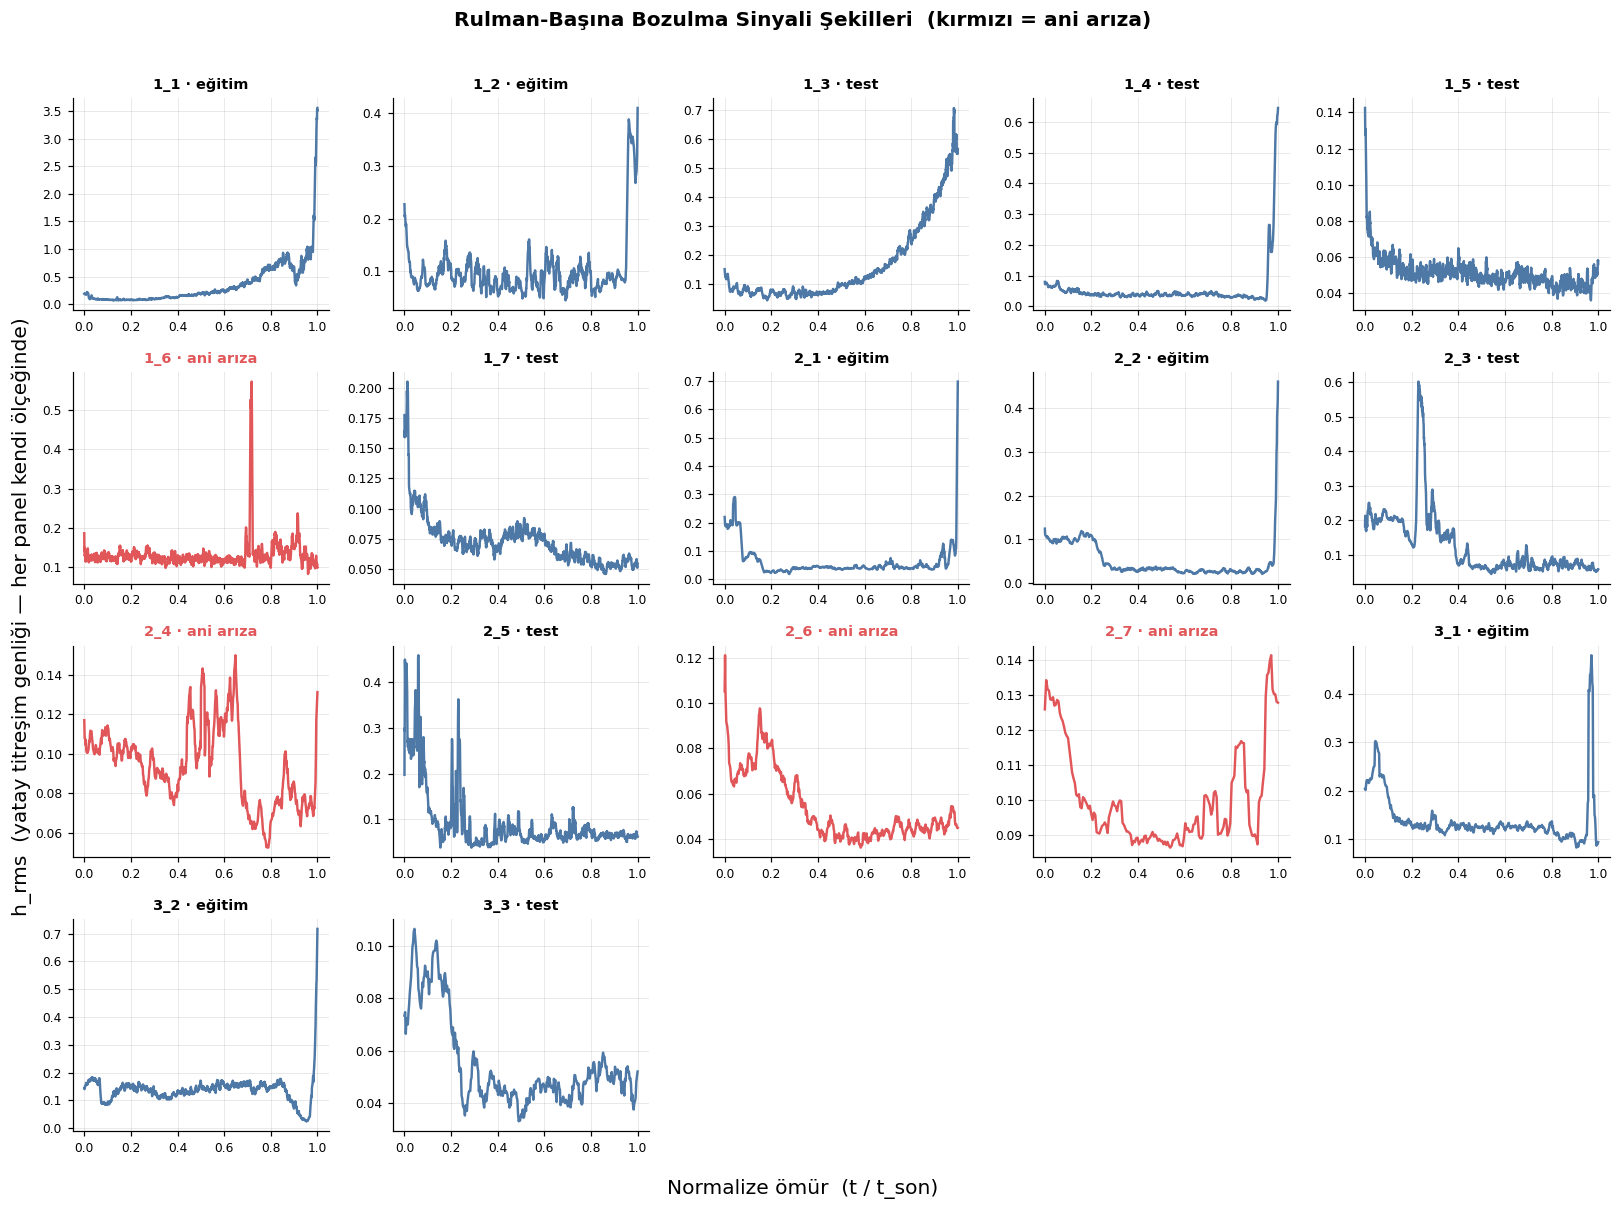

In [3]:
allb = pd.concat([TR.assign(split="train"), TE.assign(split="test")], ignore_index=True)
ANOM = {"Bearing1_6", "Bearing2_4", "Bearing2_6", "Bearing2_7"}   # ani-arıza (test)
bearings = sorted(allb["bearing"].unique())
ncol = 5; nrow = int(np.ceil(len(bearings)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.7*nrow)); axes = axes.ravel()
for i, b in enumerate(bearings):
    ax = axes[i]; g = allb[allb.bearing == b].sort_values("time_s")
    life = g["time_s"].values / g["time_s"].values.max()
    rms = pd.Series(g["h_rms"].values).rolling(10, min_periods=1).mean()
    sudden = b in ANOM
    col = C["anom"] if sudden else C["norm"]
    ax.plot(life, rms, color=col, lw=1.6)
    tag = " · ani arıza" if sudden else (" · eğitim" if g["split"].iloc[0]=="train" else " · test")
    ax.set_title(b.replace("Bearing","") + tag, fontsize=9.5,
                 color=col if sudden else "black")
    ax.tick_params(labelsize=8)
for j in range(len(bearings), len(axes)): axes[j].axis("off")
fig.supxlabel("Normalize ömür  (t / t_son)")
fig.supylabel("h_rms  (yatay titreşim genliği — her panel kendi ölçeğinde)")
fig.suptitle("Rulman-Başına Bozulma Sinyali Şekilleri  (kırmızı = ani arıza)",
             fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "gorsel_sinyal_farkliliklari.png")
plt.show()

## Şekil B — Truncation / Fiziksel Limit (5.1)

**Mesaj:** 4 rulman (1_6, 2_4, 2_6, 2_7) kesim anında gerçek HI ≈ %78-81 *bozuk* olmasına rağmen ham
titreşim genliği (`h_rms`) bir SAĞLIKLI rulmanınki kadar düşük → sinyal fiziksel olarak yok, hiçbir model
ayıramaz. **Bearing2_6 ≈ Bearing1_7** (daire içinde): aynı h_rms, zıt bozulma.

  kaydedildi → experiments/results/figures/gorsel_truncation.png


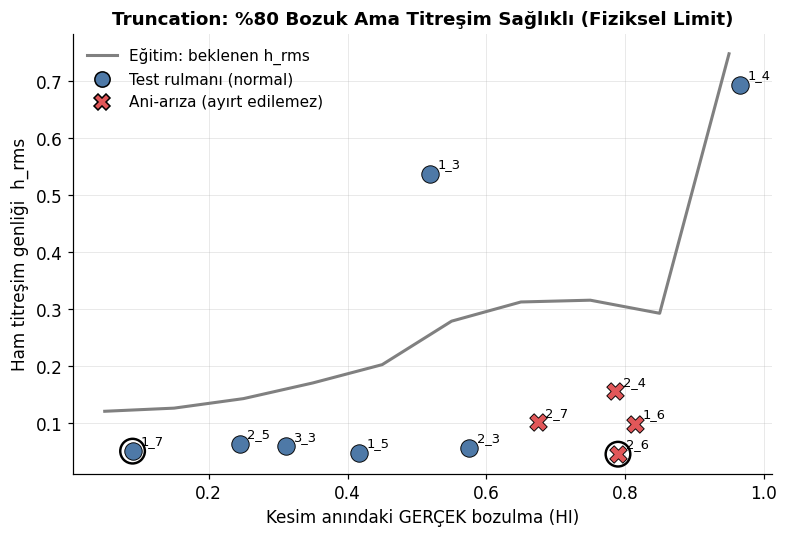

   bearing  hi_true  h_rms  anom
Bearing1_3    0.518  0.538 False
Bearing1_4    0.966  0.694 False
Bearing1_5    0.417  0.049 False
Bearing1_6    0.815  0.099  True
Bearing1_7    0.090  0.052 False
Bearing2_3    0.575  0.057 False
Bearing2_4    0.785  0.156  True
Bearing2_5    0.244  0.064 False
Bearing2_6    0.790  0.046  True
Bearing2_7    0.674  0.102  True
Bearing3_3    0.311  0.060 False


In [4]:
from config import ACTUAL_RUL_SECONDS

tr = TR.copy()
tr["hi"] = np.clip((tr["time_s"] - tr["t_star_s"]) / tr["cap_s"], 0, 1)
bins = np.linspace(0, 1, 11); ctr = 0.5*(bins[:-1]+bins[1:])
tr["hi_bin"] = pd.cut(tr["hi"], bins, labels=ctr)
ref = tr.groupby("hi_bin")["h_rms"].mean()

ANOM = {"Bearing1_6", "Bearing2_4", "Bearing2_6", "Bearing2_7"}
rows = []
for b, g in TE.groupby("bearing"):
    g = g.sort_values("time_s")
    t_star = g["t_star_s"].iloc[0]; t_last = g["time_s"].iloc[-1]
    total = t_last + ACTUAL_RUL_SECONDS[b]
    hi_true = np.clip((t_last - t_star)/max(total - t_star, 1e-6), 0, 1)
    h_rms_last = g["h_rms"].iloc[-5:].mean()
    rows.append((b, hi_true, h_rms_last, b in ANOM))
Ttab = pd.DataFrame(rows, columns=["bearing","hi_true","h_rms","anom"])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(ctr.astype(float), ref.values, "-", color="gray", lw=2)
for _, r in Ttab.iterrows():
    col = C["anom"] if r.anom else C["norm"]; mk = "X" if r.anom else "o"
    ax.scatter(r.hi_true, r.h_rms, s=130, color=col, marker=mk, zorder=3,
               edgecolor="k", linewidth=0.6)
    ax.annotate(r.bearing.replace("Bearing",""), (r.hi_true, r.h_rms),
                xytext=(5,4), textcoords="offset points", fontsize=8.5)
for b in ["Bearing2_6","Bearing1_7"]:
    r = Ttab[Ttab.bearing==b].iloc[0]
    ax.scatter(r.hi_true, r.h_rms, s=260, facecolor="none", edgecolor="k",
               linewidth=1.6, zorder=2)
ax.set_xlabel("Kesim anındaki GERÇEK bozulma (HI)")
ax.set_ylabel("Ham titreşim genliği  h_rms")
ax.set_title("Truncation: %80 Bozuk Ama Titreşim Sağlıklı (Fiziksel Limit)")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color="gray", lw=2, label="Eğitim: beklenen h_rms"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=C["norm"], markersize=10,
           markeredgecolor="k", label="Test rulmanı (normal)"),
    Line2D([0],[0], marker="X", color="w", markerfacecolor=C["anom"], markersize=11,
           markeredgecolor="k", label="Ani-arıza (ayırt edilemez)"),
], loc="upper left")
save(fig, "gorsel_truncation.png")
plt.show()
print(Ttab.round(3).to_string(index=False))

## Modellerin eğitimi (Şekil C ve D için ortak)

RF ve XGBoost train üzerinde fit edilir; LOBO ile her model için gamma seçilir (RUL okuması için).

In [5]:
from train_track_a import fit_prep_model, predict_hi_bearing
from models import RandomForestModel, XGBoostModel
from hi_labeling import (add_hi_label, smooth_hi, rul_from_hi, actual_rul_min,
                         lobo_gamma_records, pick_best_gamma, traj_corr)
from evaluation import phm_accuracy, phm_percent_error
from config import LEARNING_BEARINGS

trd = add_hi_label(TR.copy()); ted = add_hi_label(TE.copy())
factories = {
    "Random Forest": lambda: RandomForestModel(n_estimators=300, min_samples_leaf=5),
    "XGBoost":       lambda: XGBoostModel(n_estimators=400, learning_rate=0.02, max_depth=6),
}
fitted, gammas = {}, {}
for name, fac in factories.items():
    print(f"  fit + LOBO-gamma: {name} ...")
    recs = []
    for bout in LEARNING_BEARINGS:
        pf, mf = fit_prep_model(trd[trd.bearing != bout], fac)
        g = trd[trd.bearing == bout].sort_values("time_s")
        hip = predict_hi_bearing(pf, mf, g)
        recs.append(lobo_gamma_records(hip, g["time_s"].values, g["rul_s"].values,
                                        g["t_star_s"].iloc[0]))
    gammas[name] = pick_best_gamma(recs)
    fitted[name] = fit_prep_model(trd, fac)
print("  seçilen gamma:", gammas)

  fit + LOBO-gamma: Random Forest ...

=== Preprocessor Fit ===
  [Smoothing & Baseline] EMA (span=20) ve referans baseline sıfırlama...
  [Trend] Değişim hızı (ivme) özellikleri ekleniyor...
  Başlangıç öznitelik sayısı: 62
  [Variance] 8 öznitelik atıldı (std < 0.01): ['h_stft_band0_mean', 'h_stft_band2_mean', 'v_stft_band0_mean', 'v_stft_band0_std', 'v_stft_band0_max']...
  [Variance] 54 öznitelik kaldı.
  MI skorları hesaplanıyor...


  [Correlation] 15 öznitelik atıldı (r > 0.95): ['v_spectral_entropy', 'h_stft_band0_max', 'v_rms_trend', 'v_peak2peak', 'h_stft_band2_std']...
  [Correlation] 39 öznitelik kaldı.
  [MI Selection] Top 25 öznitelik seçildi.
    En yüksek 5: ['cross_rms_ratio', 'h_band_energy_0', 'h_std', 'h_band_energy_1', 'v_band_energy_1']
    En düşük  5: ['v_spectral_spread', 'h_stft_band0_std', 'v_band_energy_0', 'v_spectral_centroid', 'v_stft_band2_mean']

  Çıktı: X=(4731, 25), y=(4731,)



=== Preprocessor Fit ===
  [Smoothing & Baseline] EMA (span=20) ve referans baseline sıfırlama...
  [Trend] Değişim hızı (ivme) özellikleri ekleniyor...
  Başlangıç öznitelik sayısı: 62
  [Variance] 2 öznitelik atıldı (std < 0.01): ['h_stft_band2_mean', 'h_stft_band2_std']
  [Variance] 60 öznitelik kaldı.
  MI skorları hesaplanıyor...


  [Correlation] 19 öznitelik atıldı (r > 0.95): ['v_stft_band1_std', 'v_peak', 'h_stft_band1_max', 'v_stft_band2_std', 'v_rms']...
  [Correlation] 41 öznitelik kaldı.
  [MI Selection] Top 25 öznitelik seçildi.
    En yüksek 5: ['h_std', 'h_band_energy_0', 'h_spectral_entropy', 'v_band_energy_1', 'h_stft_band1_mean']
    En düşük  5: ['v_shape_factor', 'v_stft_band2_max', 'v_band_energy_2', 'v_stft_band0_mean', 'h_stft_band1_mean_trend']

  Çıktı: X=(6663, 25), y=(6663,)



=== Preprocessor Fit ===
  [Smoothing & Baseline] EMA (span=20) ve referans baseline sıfırlama...
  [Trend] Değişim hızı (ivme) özellikleri ekleniyor...
  Başlangıç öznitelik sayısı: 62
  [Variance] 1 öznitelik atıldı (std < 0.01): ['h_stft_band2_mean']
  [Variance] 61 öznitelik kaldı.
  MI skorları hesaplanıyor...


...


=== Preprocessor Fit ===
  [Smoothing & Baseline] EMA (span=20) ve referans baseline sıfırlama...
  [Trend] Değişim hızı (ivme) özellikleri ekleniyor...
  Başlangıç öznitelik sayısı: 62
  [Variance] 1 öznitelik atıldı (std < 0.01): ['h_stft_band2_mean']
  [Variance] 61 öznitelik kaldı.
  MI skorları hesaplanıyor...


  [Correlation] 20 öznitelik atıldı (r > 0.95): ['v_peak', 'h_stft_band1_max', 'v_rms', 'v_stft_band2_max', 'v_std']...
  [Correlation] 41 öznitelik kaldı.
  [MI Selection] Top 25 öznitelik seçildi.
    En yüksek 5: ['h_std', 'cross_rms_ratio', 'h_band_energy_0', 'v_band_energy_1', 'h_spectral_entropy']
    En düşük  5: ['v_spectral_entropy', 'v_crest_factor', 'h_skewness', 'v_stft_band2_std', 'v_kurtosis']

  Çıktı: X=(5897, 25), y=(5897,)



=== Preprocessor Fit ===
  [Smoothing & Baseline] EMA (span=20) ve referans baseline sıfırlama...
  [Trend] Değişim hızı (ivme) özellikleri ekleniyor...
  Başlangıç öznitelik sayısı: 62
  [Variance] 2 öznitelik atıldı (std < 0.01): ['h_stft_band2_mean', 'h_stft_band2_std']
  [Variance] 60 öznitelik kaldı.
  MI skorları hesaplanıyor...


  [Correlation] 19 öznitelik atıldı (r > 0.95): ['v_peak', 'h_stft_band1_max', 'v_stft_band2_std', 'v_rms', 'v_stft_band2_max']...
  [Correlation] 41 öznitelik kaldı.
  [MI Selection] Top 25 öznitelik seçildi.
    En yüksek 5: ['h_std', 'h_band_energy_0', 'h_band_energy_1', 'h_spectral_entropy', 'cross_rms_ratio']
    En düşük  5: ['v_shape_factor', 'v_stft_band2_mean', 'h_stft_band2_tratio', 'v_stft_band0_mean', 'v_crest_factor']

  Çıktı: X=(7534, 25), y=(7534,)


  seçilen gamma: {'Random Forest': 0.4, 'XGBoost': 0.3}


## Şekil C — RF / XGBoost HI Trajektorileri (4.2)

Gerçek HI (siyah) vs tahmin edilen yumuşatılmış HI (rulman-içi şekil takibi).

  kaydedildi → experiments/results/figures/gorsel_trajektori_ml.png


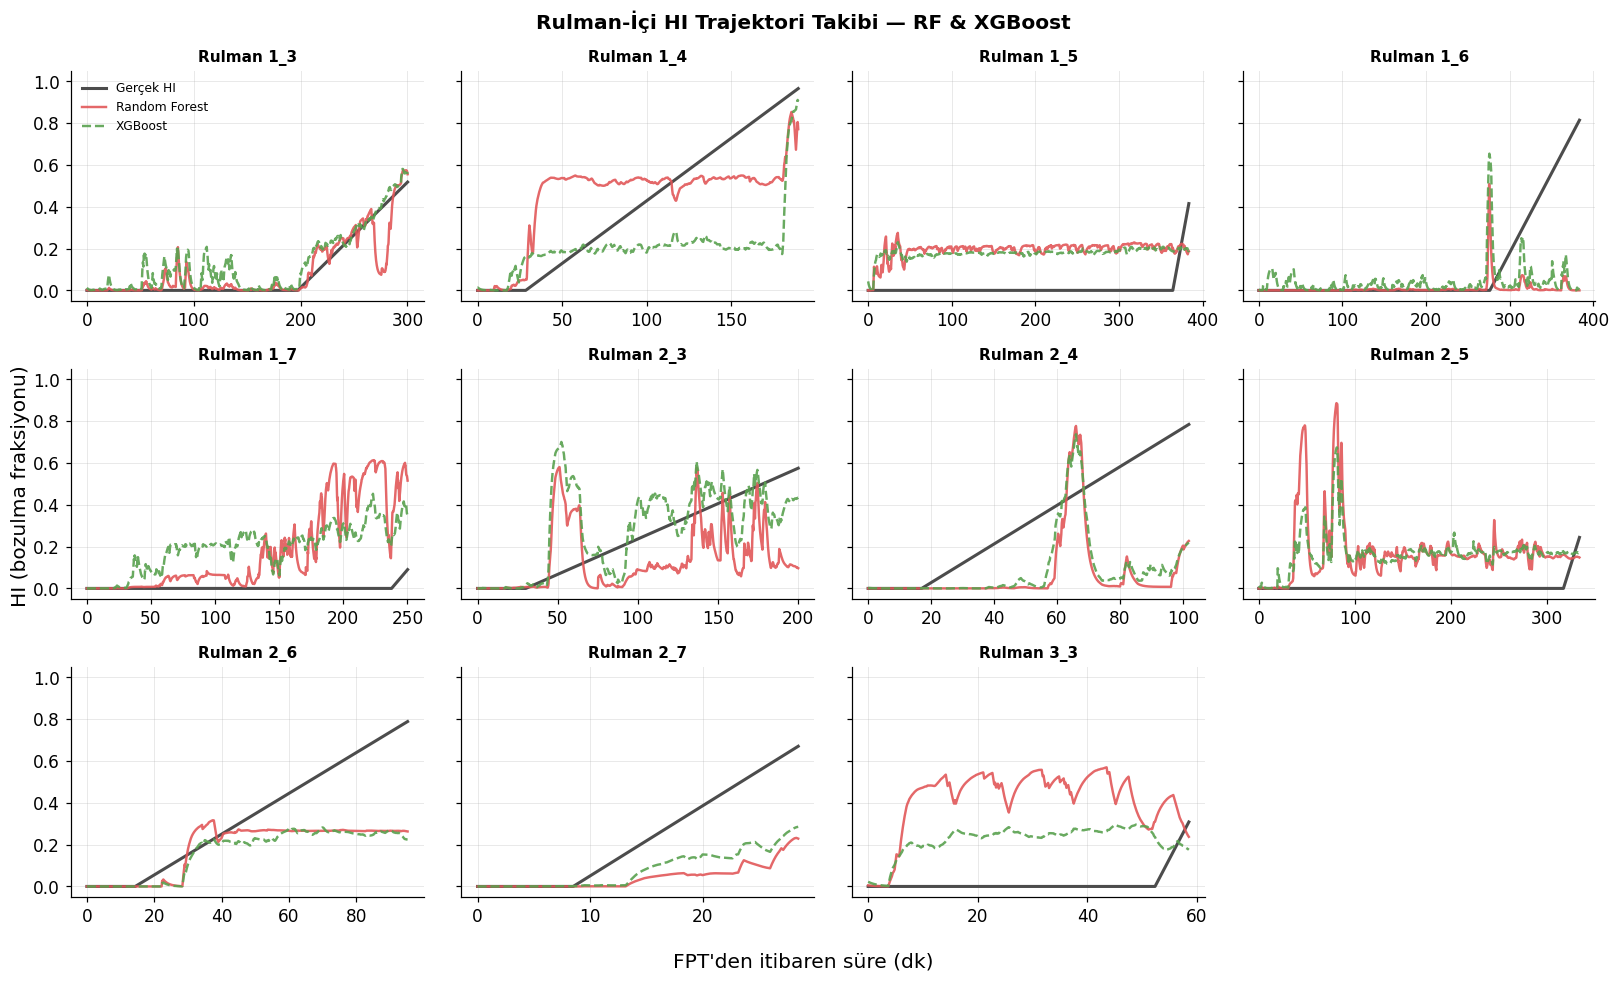

In [6]:
bearings = sorted(ted["bearing"].unique())
fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharey=True); axes = axes.ravel()
for i, b in enumerate(bearings):
    ax = axes[i]; g = ted[ted.bearing == b].sort_values("time_s")
    t = (g["time_s"] - g["time_s"].min())/60.0
    ax.plot(t, g["hi"].values, color=C["actual"], lw=2, label="Gerçek HI")
    for name, col, ls in [("Random Forest", C["rf"], "-"), ("XGBoost", C["xgb"], "--")]:
        prep, mdl = fitted[name]
        ax.plot(t, smooth_hi(predict_hi_bearing(prep, mdl, g), 1.0),
                color=col, ls=ls, lw=1.6, label=name, alpha=0.9)
    ax.set_title(b.replace("Bearing","Rulman "), fontsize=10); ax.set_ylim(-0.05, 1.05)
for j in range(len(bearings), len(axes)): axes[j].axis("off")
axes[0].legend(loc="upper left", fontsize=8)
fig.supxlabel("FPT'den itibaren süre (dk)"); fig.supylabel("HI (bozulma fraksiyonu)")
fig.suptitle("Rulman-İçi HI Trajektori Takibi — RF & XGBoost", fontweight="bold")
fig.tight_layout(); save(fig, "gorsel_trajektori_ml.png"); plt.show()

## Tablo + Şekil D — Rulman-Başına Tahmin (4.1)

Her test rulmanı için: gerçek RUL, RF/XGB tahmini, mutlak hata ve **rulman-başına PHM doğruluğu**.
Tablo `tablo_yatak_tahmin.csv`'ye, grafik `gorsel_yatak_tahmin.png`'e kaydedilir.

 bearing kosul gercek_RUL_dk Random Forest_tahmin  Random Forest_hata  Random Forest_PHM XGBoost_tahmin  XGBoost_hata  XGBoost_PHM
     1_3     1          95.7                 27.3                68.4              0.084           19.8          75.9        0.064
     1_4     1           5.8                 18.9                13.1              0.000            5.1           0.7        0.656
     1_5     1          27.0                 18.3                 8.7              0.329           12.4          14.6        0.154
     1_6     1          24.5                125.0               100.5              0.000          125.0         100.5        0.000
     1_7     1         125.0                  3.8               121.2              0.035            4.7         120.3        0.036
     2_3     2         125.0                125.0                 0.0              1.000           48.4          76.6        0.120
     2_4     2          23.3                 73.4                50.1              

  kaydedildi → experiments/results/figures/gorsel_yatak_tahmin.png


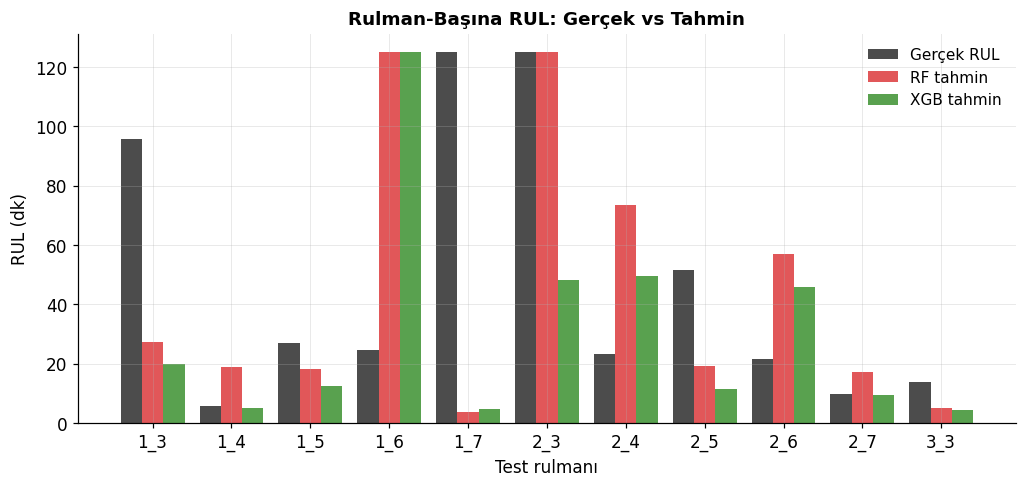

In [7]:
rec = {}
for name in factories:
    prep, mdl = fitted[name]; g_star = gammas[name]
    for b, g in ted.groupby("bearing"):
        g = g.sort_values("time_s")
        hip = predict_hi_bearing(prep, mdl, g)
        pred = rul_from_hi(hip, g["time_s"].values, g["t_star_s"].iloc[0], g_star)
        act = actual_rul_min(g)
        rec.setdefault(b, {"bearing": b, "kosul": int(g["condition"].iloc[0]),
                           "gercek_RUL_dk": round(act, 1)})
        rec[b][f"{name}_tahmin"] = round(pred, 1)
        rec[b][f"{name}_hata"]   = round(abs(act - pred), 1)
        rec[b][f"{name}_PHM"]    = round(phm_accuracy(phm_percent_error(act, pred)), 3)

tbl = pd.DataFrame(rec.values()).sort_values("bearing").reset_index(drop=True)
tbl["bearing"] = tbl["bearing"].str.replace("Bearing", "")
# ortalama satırı
avg = {"bearing": "ORTALAMA", "kosul": "", "gercek_RUL_dk": ""}
for name in factories:
    avg[f"{name}_tahmin"] = ""
    avg[f"{name}_hata"] = round(tbl[f"{name}_hata"].mean(), 1)
    avg[f"{name}_PHM"]  = round(tbl[f"{name}_PHM"].mean(), 3)
tbl_full = pd.concat([tbl, pd.DataFrame([avg])], ignore_index=True)
tbl_full.to_csv(BASE/"experiments"/"results"/"tablo_yatak_tahmin.csv", index=False)
print(tbl_full.to_string(index=False))

# Grafik: rulman-başına gerçek vs RF vs XGB
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(tbl)); w = 0.27
ax.bar(x - w, tbl["gercek_RUL_dk"], w, label="Gerçek RUL", color=C["actual"])
ax.bar(x,     tbl["Random Forest_tahmin"], w, label="RF tahmin", color=C["rf"])
ax.bar(x + w, tbl["XGBoost_tahmin"], w, label="XGB tahmin", color=C["xgb"])
ax.set_xticks(x); ax.set_xticklabels(tbl["bearing"], rotation=0)
ax.set_xlabel("Test rulmanı"); ax.set_ylabel("RUL (dk)")
ax.set_title("Rulman-Başına RUL: Gerçek vs Tahmin")
ax.legend(loc="upper right")
save(fig, "gorsel_yatak_tahmin.png"); plt.show()

---
# Colab-Bekleyen Görseller (Track B)

`experiments/results/track_b_results.csv` ve Track B prediction çıktıları gelince otomatik dolar.
Yoksa doğrulanmış önceki koşu değerleri **placeholder** olarak kullanılır + uyarı bandı konur.

## Şekil E — 5-Model Karşılaştırma: PHM & endpoint_r (4.1)

  kaydedildi → experiments/results/figures/gorsel_model_karsilastirma.png


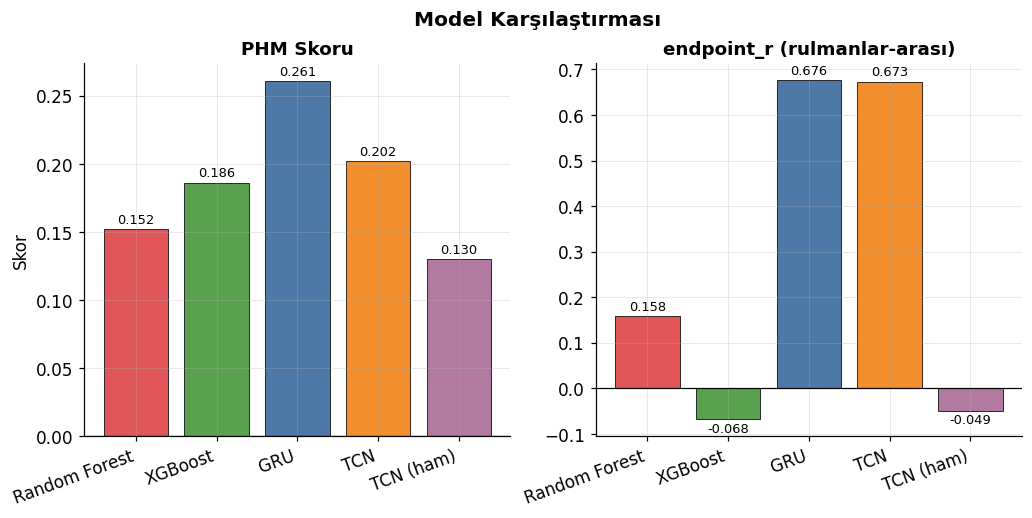

In [8]:
ta_path = BASE/"experiments"/"results"/"track_a_results.csv"
tb_path = BASE/"experiments"/"results"/"track_b_results.csv"
ta = pd.read_csv(ta_path) if ta_path.exists() else pd.DataFrame(
    [("Random Forest",0.152,0.158),("XGBoost",0.186,-0.068)],
    columns=["model","phm","endpoint_r"])
PLACEHOLDER_B = pd.DataFrame([
    ("GRU",0.261,0.676,0.34,0.584),("TCN",0.202,0.673,0.28,0.325),
    ("raw-TCN",0.130,-0.049,0.44,0.629)],
    columns=["model","phm","endpoint_r","traj_r","lobo_traj_r"])
is_placeholder = not tb_path.exists()
tb = pd.read_csv(tb_path) if tb_path.exists() else PLACEHOLDER_B.copy()

allm = pd.concat([ta[["model","phm","endpoint_r"]], tb[["model","phm","endpoint_r"]]],
                 ignore_index=True)
order = ["Random Forest","XGBoost","GRU","TCN","raw-TCN"]
allm = allm.set_index("model").reindex(order).reset_index()
cols = [C["rf"],C["xgb"],C["gru"],C["tcn"],C["rawtcn"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
xpos = np.arange(len(allm))
for ax, metric, ttl in [(axes[0],"phm","PHM Skoru"),
                        (axes[1],"endpoint_r","endpoint_r (rulmanlar-arası)")]:
    bars = ax.bar(xpos, allm[metric], color=cols, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", lw=0.8)
    for b,v in zip(bars, allm[metric]):
        ax.annotate(f"{v:.3f}", (b.get_x()+b.get_width()/2, v), ha="center",
                    va="bottom" if v>=0 else "top", fontsize=8.5,
                    xytext=(0,2 if v>=0 else -2), textcoords="offset points")
    ax.set_xticks(xpos)
    ax.set_xticklabels([DISP.get(m, m) for m in allm["model"]], rotation=20, ha="right")
    ax.set_title(ttl)
axes[0].set_ylabel("Skor")
if is_placeholder:
    fig.text(0.5, 1.04, "⚠ DL değerleri PLACEHOLDER — Track B Colab koşusu bekliyor",
             ha="center", color=C["anom"], fontsize=10, fontweight="bold")
fig.suptitle("Model Karşılaştırması", y=0.99 if not is_placeholder else 0.96, fontweight="bold")
save(fig, "gorsel_model_karsilastirma.png"); plt.show()

## Şekil F — GRU/TCN/raw-TCN: Rulman-Başına RUL Tahmini (4.2)

DL modellerinin yatak-başına gerçek vs tahmin RUL'u (Track B Colab koşusundan). **Mesaj:** GRU/TCN
ani-arıza rulmanlarını (1_6, 2_4) 125'e şişiriyor ama gerisinde makul; raw-TCN ise savruk
(2_6/2_7→125, 1_7→~1) → mutlak RUL'u genelleyemiyor (RQ2).

  kaydedildi → experiments/results/figures/gorsel_dl_rulman_tahmin.png


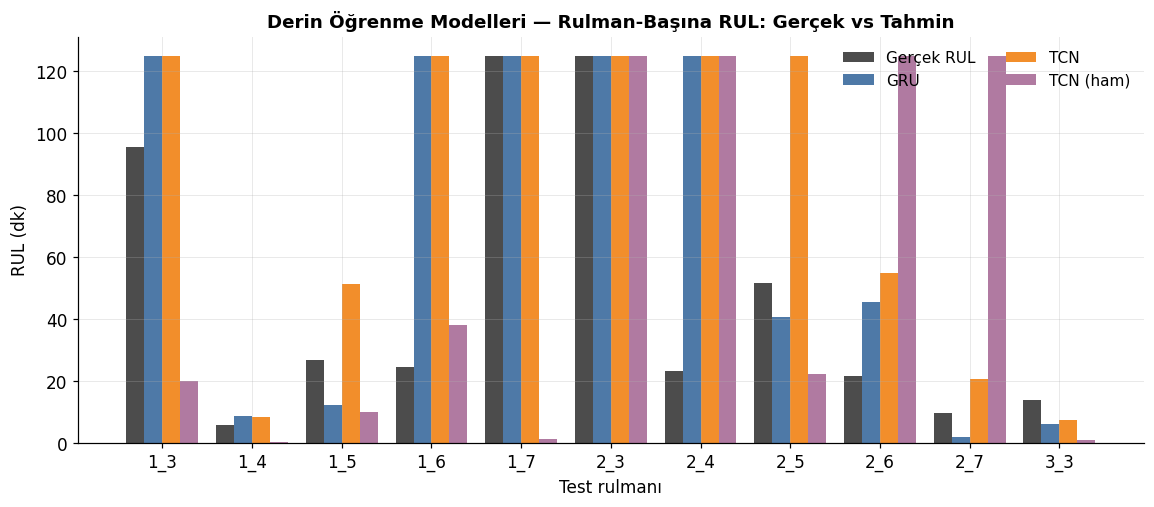

In [9]:
# Track B yatak-başına gerçek/tahmin (Colab çıktısı, 2026-06-18)
dl_order = ["1_3","1_4","1_5","1_6","1_7","2_3","2_4","2_5","2_6","2_7","3_3"]
dl_act = {"1_3":95.7,"1_4":5.8,"1_5":27.0,"1_6":24.5,"1_7":125.0,"2_3":125.0,
          "2_4":23.3,"2_5":51.7,"2_6":21.7,"2_7":9.8,"3_3":13.8}
dl_pred = {
 "GRU":     {"1_3":125,"1_4":8.7,"1_5":12.2,"1_6":125,"1_7":125,"2_3":125,"2_4":125,"2_5":40.9,"2_6":45.6,"2_7":2.0,"3_3":6.3},
 "TCN":     {"1_3":125,"1_4":8.5,"1_5":51.3,"1_6":125,"1_7":125,"2_3":125,"2_4":125,"2_5":125,"2_6":54.8,"2_7":20.7,"3_3":7.5},
 "raw-TCN": {"1_3":20.1,"1_4":0.4,"1_5":10.1,"1_6":38.1,"1_7":1.4,"2_3":125,"2_4":125,"2_5":22.4,"2_6":125,"2_7":125,"3_3":0.9},
}
x = np.arange(len(dl_order)); w = 0.2
fig, ax = plt.subplots(figsize=(12.5, 4.8))
ax.bar(x - 1.5*w, [dl_act[b] for b in dl_order], w, label="Gerçek RUL", color=C["actual"])
ax.bar(x - 0.5*w, [dl_pred["GRU"][b] for b in dl_order], w, label="GRU", color=C["gru"])
ax.bar(x + 0.5*w, [dl_pred["TCN"][b] for b in dl_order], w, label="TCN", color=C["tcn"])
ax.bar(x + 1.5*w, [dl_pred["raw-TCN"][b] for b in dl_order], w, label="TCN (ham)", color=C["rawtcn"])
ax.set_xticks(x); ax.set_xticklabels(dl_order)
ax.set_xlabel("Test rulmanı"); ax.set_ylabel("RUL (dk)")
ax.set_title("Derin Öğrenme Modelleri — Rulman-Başına RUL: Gerçek vs Tahmin")
ax.legend(loc="upper right", ncol=2)
save(fig, "gorsel_dl_rulman_tahmin.png"); plt.show()

## Şekil I — DL HI Trajektorileri: Gerçek vs Tahmin (4.2)

**Asıl istenen görsel:** GRU/TCN/TCN(ham) modellerinin yatak-içi HI eğrisini (şekil takibi) gerçek HI
ile karşılaştırır — sadece son nokta değil. `experiments/results/track_b_predictions.npz` gelince
otomatik çizilir. Beklenen format: anahtar `"MODEL__BearingX_Y"` → pencere-sırasıyla tahmin HI dizisi.

In [10]:
TBP = BASE/"experiments"/"results"/"track_b_predictions.npz"
if not TBP.exists():
    print("⏳ track_b_predictions.npz yok. Colab export snippet'i (sohbette verildi) ile üretip"
          "\n   experiments/results/ altına koyunca bu hücre DL trajektorilerini çizecek.")
else:
    d = np.load(TBP, allow_pickle=True)
    models = [("GRU", C["gru"]), ("TCN", C["tcn"]), ("raw-TCN", C["rawtcn"])]
    bs = sorted(TE["bearing"].unique())
    fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharey=True); axes = axes.ravel()
    for i, b in enumerate(bs):
        ax = axes[i]; g = TE[TE.bearing == b].sort_values("time_s")
        hi_true = np.clip((g["time_s"].values - g["t_star_s"].iloc[0]) / g["cap_s"].iloc[0], 0, 1)
        t = (g["time_s"].values - g["time_s"].values.min()) / 60.0
        ax.plot(t, hi_true, color=C["actual"], lw=2, label="Gerçek HI")
        for m, col in models:
            key = f"{m}__{b}"
            if key in d.files:
                hp = np.asarray(d[key], float)
                ax.plot(t[:len(hp)], hp, color=col, lw=1.5, label=DISP.get(m, m), alpha=0.9)
        ax.set_title(b.replace("Bearing", "Rulman "), fontsize=10); ax.set_ylim(-0.05, 1.05)
    for j in range(len(bs), len(axes)): axes[j].axis("off")
    axes[0].legend(fontsize=8, loc="upper left")
    fig.supxlabel("FPT'den itibaren süre (dk)"); fig.supylabel("HI (bozulma fraksiyonu)")
    fig.suptitle("Derin Öğrenme — Rulman-İçi HI Trajektori Takibi", fontweight="bold")
    fig.tight_layout(); save(fig, "gorsel_dl_trajektori.png"); plt.show()

⏳ track_b_predictions.npz yok. Colab export snippet'i (sohbette verildi) ile üretip
   experiments/results/ altına koyunca bu hücre DL trajektorilerini çizecek.


## Şekil G — raw-TCN vs Feature-DL: RQ2 (5.2)

raw-TCN bozulma *şeklini* genelliyor (LOBO traj_r yüksek) ama mutlak RUL'u genelleyemiyor
(endpoint_r≈0) → otomatik FE, manuel FE'yi yakalayamıyor.

  kaydedildi → experiments/results/figures/gorsel_rq2_rawtcn.png


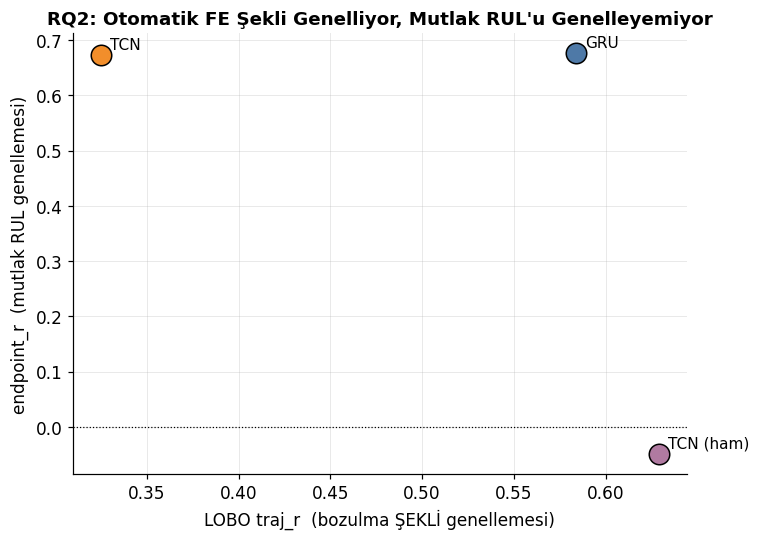

In [11]:
src6 = tb if not is_placeholder else PLACEHOLDER_B
if not {"model","endpoint_r","lobo_traj_r"}.issubset(src6.columns):
    print("⏳ lobo_traj_r kolonu yok. Track B sonucu bekleniyor.")
else:
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    cmap = {"GRU":C["gru"],"TCN":C["tcn"],"raw-TCN":C["rawtcn"]}
    for _, r in src6.iterrows():
        ax.scatter(r["lobo_traj_r"], r["endpoint_r"], s=180,
                   color=cmap.get(r["model"],"gray"), edgecolor="k", zorder=3)
        ax.annotate(DISP.get(r["model"], r["model"]), (r["lobo_traj_r"], r["endpoint_r"]),
                    xytext=(6,4), textcoords="offset points", fontsize=10)
    ax.axhline(0, color="k", lw=0.8, ls=":")
    ax.set_xlabel("LOBO traj_r  (bozulma ŞEKLİ genellemesi)")
    ax.set_ylabel("endpoint_r  (mutlak RUL genellemesi)")
    ax.set_title("RQ2: Otomatik FE Şekli Genelliyor, Mutlak RUL'u Genelleyemiyor")
    if is_placeholder:
        ax.text(0.5, 1.04, "⚠ PLACEHOLDER — Track B bekliyor", transform=ax.transAxes,
                ha="center", color=C["anom"], fontsize=9, fontweight="bold")
    save(fig, "gorsel_rq2_rawtcn.png"); plt.show()